# <center>Factor Regressions</center>

$$ R_t - R_{f,t} = \alpha + \beta_1 (Mkt - R_f)_t + \beta_2 SMB_t + \beta_3 HML_t + \beta_4 RMW_t + \beta_5 CMA_t + \beta_6 MOM_t + \epsilon_t $$

In [154]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import getFamaFrenchFactors as gff

In [155]:
rets=yf.download(['VTI','AVUV','VLUE'],interval='1mo',start='1900-01-01',auto_adjust=True)['Close']
rets=rets.to_period('M').pct_change().dropna()

[*********************100%***********************]  3 of 3 completed


<Axes: xlabel='Date'>

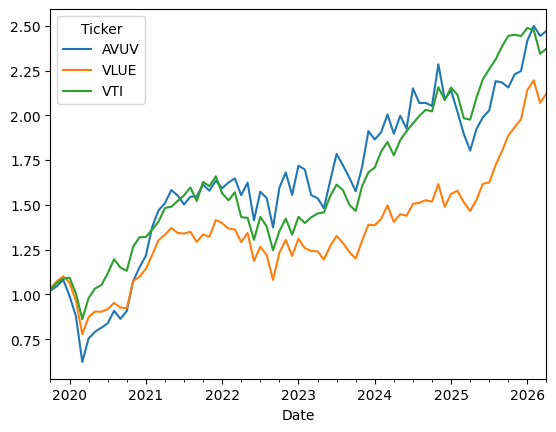

In [156]:
(1+rets).cumprod().plot()

In [157]:
fft_5_factor_model = gff.famaFrench5Factor().set_index('date_ff_factors').to_period('M')
ff_momentum_factor = gff.momentumFactor().set_index('date_ff_factors').to_period('M')

fft_6_factor_model = fft_5_factor_model.join(ff_momentum_factor)
fft_6_factor_model = fft_6_factor_model[[*fft_6_factor_model.columns.drop('RF'),'RF']]

In [158]:
fft_6_factor_model

,Mkt-RF,SMB,HML,RMW,CMA,MOM,RF
date_ff_factors,,,,,,,
1963-07,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0101,0.0027
1963-08,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0100,0.0025
1963-09,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0012,0.0027
1963-10,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0313,0.0029
1963-11,-0.0086,-0.0085,0.0173,-0.0043,0.0227,-0.0078,0.0027
...,...,...,...,...,...,...,...
2025-10,0.0196,-0.0131,-0.0310,-0.0524,-0.0403,0.0027,0.0037
2025-11,-0.0013,0.0147,0.0376,0.0144,0.0068,-0.0180,0.0030
2025-12,-0.0036,-0.0022,0.0242,0.0040,0.0037,-0.0241,0.0034


<Axes: xlabel='date_ff_factors'>

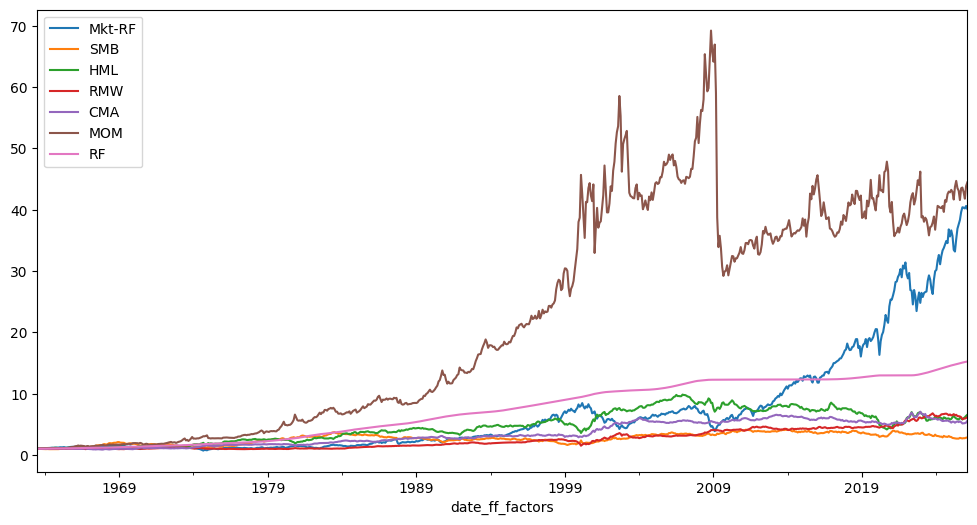

In [159]:
(1+fft_6_factor_model).cumprod().plot(figsize=(12,6))

In [160]:
def factor_regression(rets, factor_model):
    common_idx = rets.index.intersection(factor_model.index)
    rets = rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]
    
    rets_excess = rets.sub(factor_model['RF'], axis=0)
    factor_model_minus_RF = factor_model[[*fft_6_factor_model.columns.drop('RF')]]
    factor_model_minus_RF['Alpha'] = 1

    lm=sm.OLS(rets_excess,factor_model_minus_RF).fit()
    factor_loadings = lm.params
    factor_loadings.columns = rets.columns

    alpha_per_period = factor_loadings.loc[['Alpha']]
    annualized_alpha = ((1+alpha_per_period)**12)-1
    annualized_alpha.index = ['Annualized Alpha']

    factor_loadings=pd.concat([factor_loadings,annualized_alpha])
    factor_loadings=factor_loadings.astype(object)
    factor_loadings.loc[['Alpha']] = (alpha_per_period  * 100).astype(str) + ' %'
    factor_loadings.loc[['Annualized Alpha']] = (annualized_alpha * 100).astype(str) + ' %'
    return factor_loadings

In [161]:
rets

Ticker,AVUV,VLUE,VTI
Date,,,
2019-10,0.021253,0.035217,0.025738
2019-11,0.024074,0.036980,0.037878
2019-12,0.035338,0.025603,0.022497
2020-01,-0.084041,-0.031156,0.004808
2020-02,-0.112723,-0.096363,-0.079990
...,...,...,...
2025-12,0.008405,0.022892,-0.003092
2026-01,0.075385,0.082855,0.018689
2026-02,0.033953,0.024528,-0.005285


In [162]:
factor_regression(rets, fft_6_factor_model)

Ticker,AVUV,VLUE,VTI
Mkt-RF,1.078043,0.962796,1.007037
SMB,0.899626,0.124072,-0.0057
HML,0.56145,0.431741,0.05236
RMW,0.275506,-0.019363,0.030062
CMA,-0.080122,0.128082,-0.036739
MOM,0.013175,-0.086971,0.015597
Alpha,0.0366283634211815 %,-0.1189651724616719 %,-0.048925740831445394 %
Annualized Alpha,0.44042692349348656 %,-1.4182782214463563 %,-0.5855316031149638 %


In [163]:
def rolling_factor_regression(rets, factor_model, roll_window=36): # 3 years
    common_idx = rets.index.intersection(factor_model.index)
    rets = rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]

    rets_excess = rets.sub(factor_model['RF'], axis=0)
    factor_model_minus_RF = factor_model[[*fft_6_factor_model.columns.drop('RF')]]

    n_periods=rets.shape[0]
    windows=[(start, start+roll_window) for start in range(n_periods-roll_window+1)]
    if n_periods<=roll_window:
        print('Sample smaller than roll window')
        return 

    results = {}
    for ret_access in rets_excess:
        factor_loading_per_window = []
        for win in windows:
            lm=sm.OLS(rets_excess[ret_access].iloc[win[0]:win[1]], factor_model_minus_RF.iloc[win[0]:win[1]]).fit()
            factor_loadings=lm.params
            factor_loadings['date']=rets_excess.index[win[1]-1]
            factor_loading_per_window.append(factor_loadings)
        results[ret_access] = pd.DataFrame(factor_loading_per_window).set_index('date')

    return results

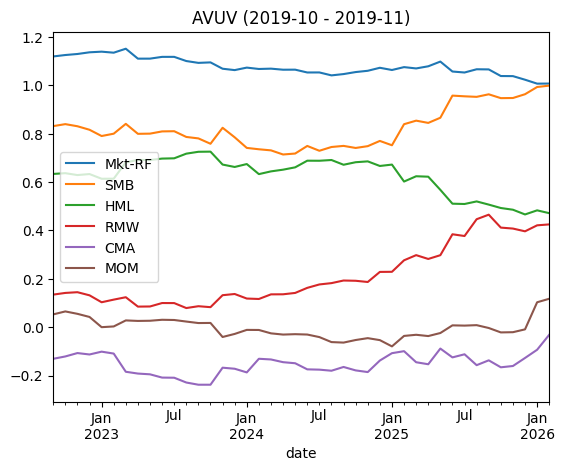

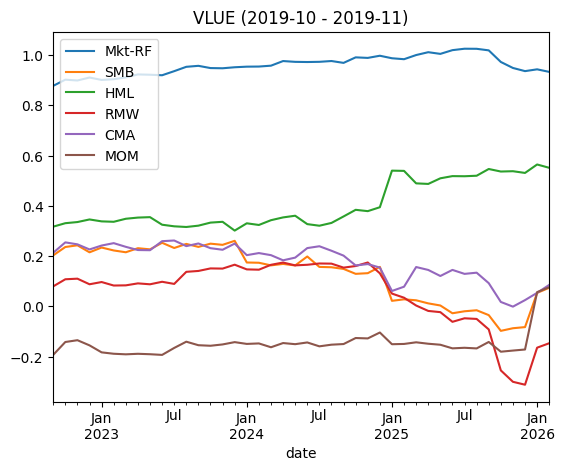

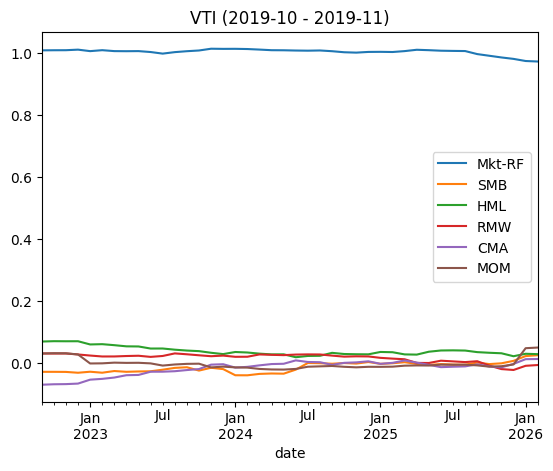

In [170]:
results = rolling_factor_regression(rets, fft_6_factor_model)
for ticker in results:
    results[ticker].plot(title=f'{ticker} ({rets.index[0]} - {rets.index[1]})')